In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load the dataset
df = pd.read_csv('titanic.csv')
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (418, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
# Basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327

In [4]:
# Statistical summary
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


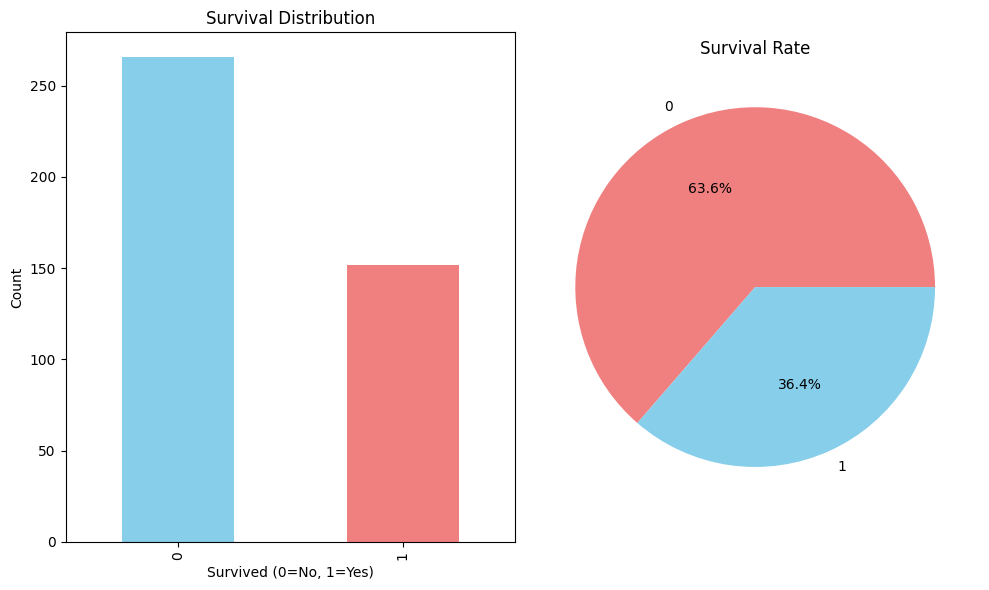

In [5]:
# %% [markdown]
# ## Data Exploration and Visualization
# Survival distribution
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
df['Survived'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Survival Distribution')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df['Survived'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral', 'skyblue'])
plt.title('Survival Rate')
plt.ylabel('')
plt.tight_layout()
plt.show()



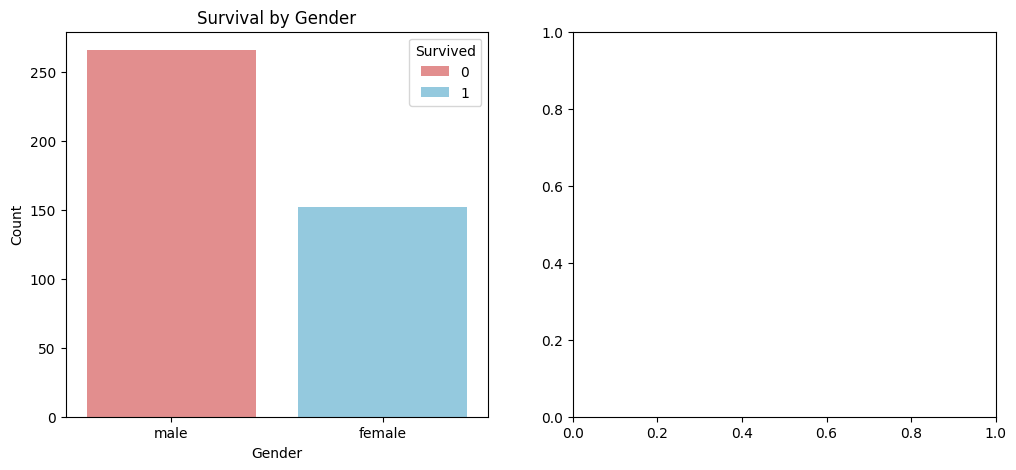

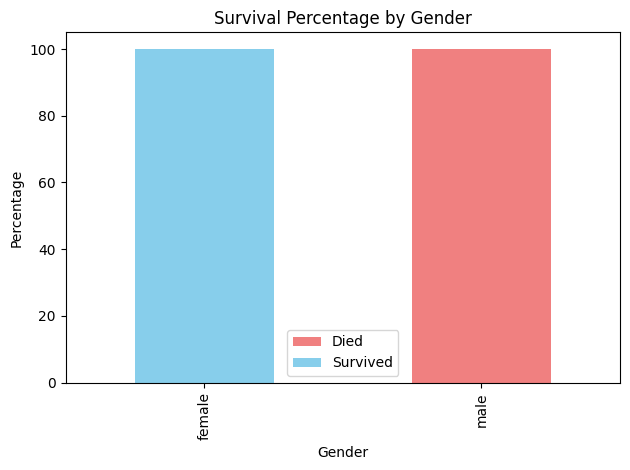

In [6]:
# Survival by gender
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Sex', hue='Survived', palette=['lightcoral', 'skyblue'])
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
survival_by_gender = pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100
survival_by_gender.plot(kind='bar', stacked=True, color=['lightcoral', 'skyblue'])
plt.title('Survival Percentage by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.legend(['Died', 'Survived'])
plt.tight_layout()
plt.show()


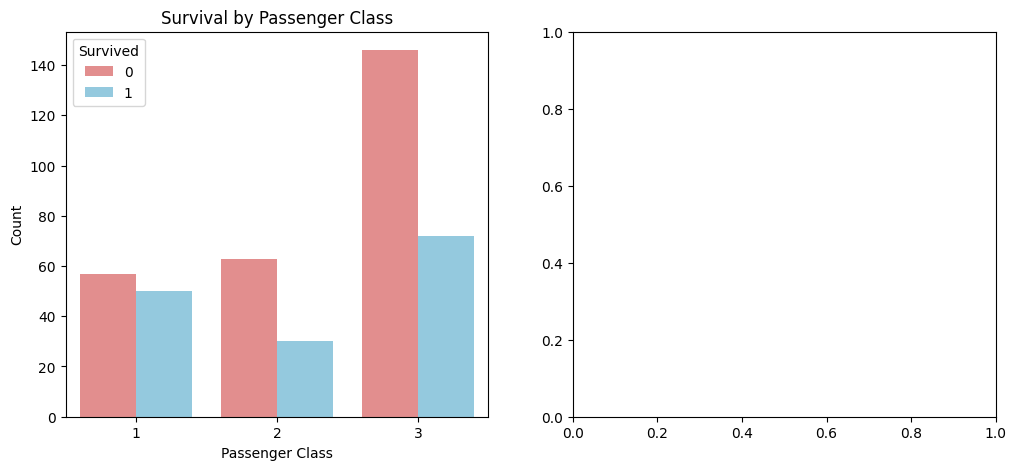

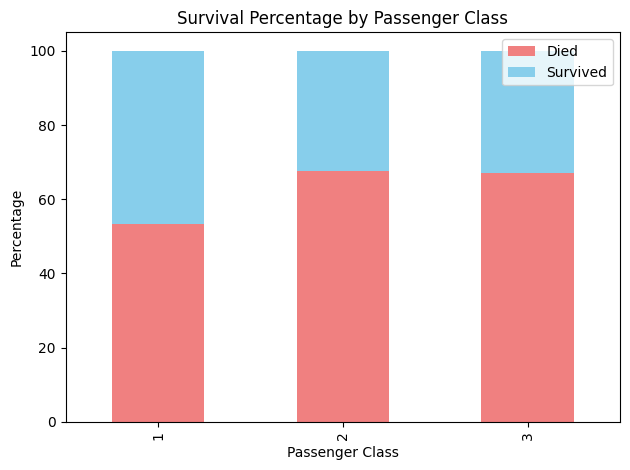

In [7]:
# Survival by passenger class
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Pclass', hue='Survived', palette=['lightcoral', 'skyblue'])
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
survival_by_class = pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100
survival_by_class.plot(kind='bar', stacked=True, color=['lightcoral', 'skyblue'])
plt.title('Survival Percentage by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Percentage')
plt.legend(['Died', 'Survived'])
plt.tight_layout()
plt.show()


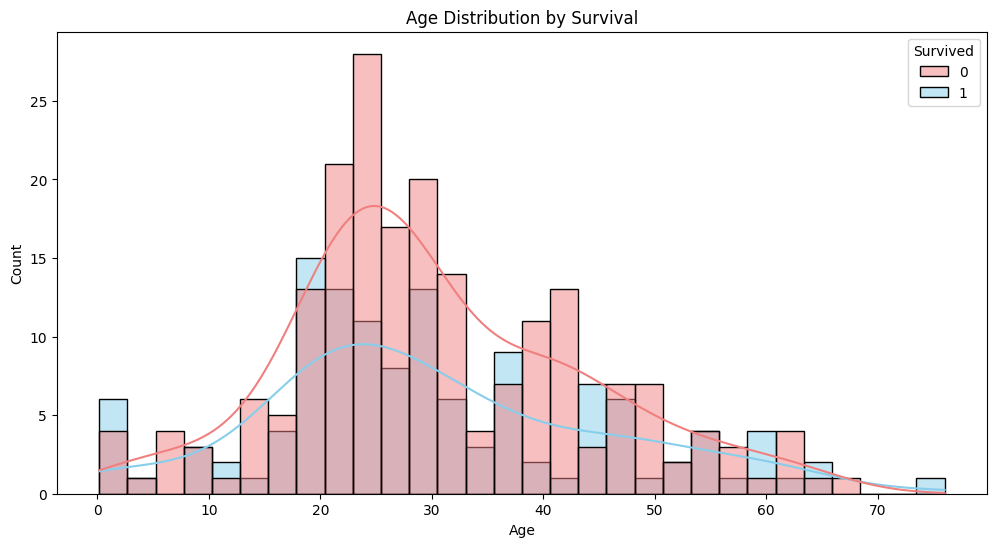

In [8]:
# Age distribution by survival
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, palette=['lightcoral', 'skyblue'], bins=30)
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


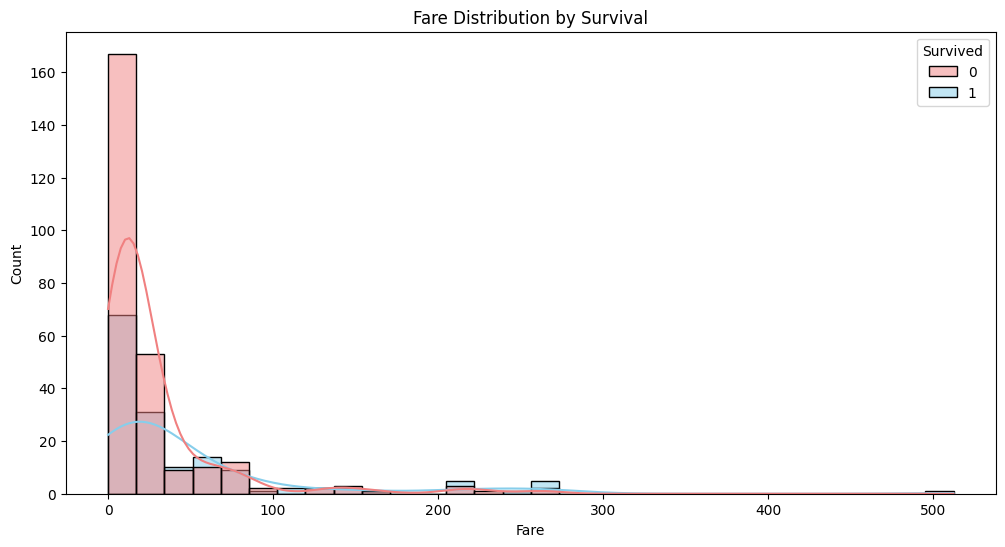

In [9]:
# Fare distribution by survival
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Fare', hue='Survived', kde=True, palette=['lightcoral', 'skyblue'], bins=30)
plt.title('Fare Distribution by Survival')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()


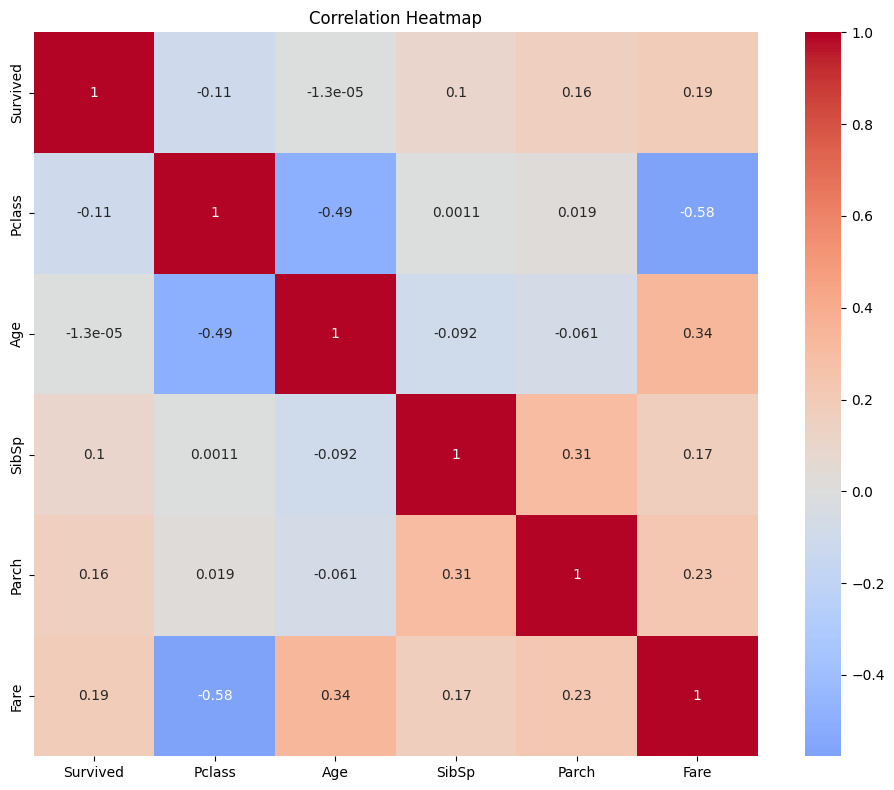

In [10]:
# Correlation heatmap for numerical features
plt.figure(figsize=(10, 8))
numerical_features = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [11]:
# Create a copy of the dataframe for preprocessing
df_processed = df.copy()


In [12]:
# Handle missing values
print("Missing values before preprocessing:")
print(df_processed.isnull().sum())


Missing values before preprocessing:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [13]:
# Fill missing Age with median grouped by Pclass and Sex
df_processed['Age'] = df_processed.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))


In [14]:
# Fill missing Fare with median of respective Pclass
df_processed['Fare'] = df_processed.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))


In [15]:
# Fill Embarked with mode
df_processed['Embarked'] = df_processed['Embarked'].fillna(df_processed['Embarked'].mode()[0])


In [16]:
# Cabin has too many missing values, we'll drop it
df_processed = df_processed.drop(['Cabin'], axis=1)


In [17]:
# Drop other unnecessary columns
df_processed = df_processed.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

print("\nMissing values after preprocessing:")
print(df_processed.isnull().sum())



Missing values after preprocessing:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [18]:
# Create family size feature
df_processed['FamilySize'] = df_processed['SibSp'] + df_processed['Parch'] + 1



In [19]:
# Create is alone feature
df_processed['IsAlone'] = (df_processed['FamilySize'] == 1).astype(int)


In [20]:
# Create age groups
df_processed['AgeGroup'] = pd.cut(df_processed['Age'], bins=[0, 12, 18, 35, 60, 100], 
                                labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])



In [21]:
# Create fare groups
df_processed['FareGroup'] = pd.qcut(df_processed['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])

df_processed.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,AgeGroup,FareGroup
0,0,3,male,34.5,0,0,7.8292,Q,1,1,Adult,Low
1,1,3,female,47.0,1,0,7.0000,S,2,0,Middle,Low
2,0,2,male,62.0,0,0,9.6875,Q,1,1,Senior,Medium
3,0,3,male,27.0,0,0,8.6625,S,1,1,Adult,Medium
4,1,3,female,22.0,1,1,12.2875,S,3,0,Adult,Medium


In [22]:
# Encode categorical variables
label_encoders = {}

categorical_columns = ['Sex', 'Embarked', 'AgeGroup', 'FareGroup']
for col in categorical_columns:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le


In [23]:
# Display the processed dataframe
df_processed.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,AgeGroup,FareGroup
0,0,3,1,34.5,0,0,7.8292,1,1,1,0,1
1,1,3,0,47.0,1,0,7.0000,2,2,0,2,1
2,0,2,1,62.0,0,0,9.6875,1,1,1,3,2
3,0,3,1,27.0,0,0,8.6625,2,1,1,0,2
4,1,3,0,22.0,1,1,12.2875,2,3,0,0,2


In [24]:
# Prepare features and target
X = df_processed.drop('Survived', axis=1)
y = df_processed['Survived']

print("Feature columns:", X.columns.tolist())
print("Target distribution:\n", y.value_counts())


Feature columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareGroup']
Target distribution:
 Survived
0    266
1    152
Name: count, dtype: int64


In [25]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")


Training set size: (334, 11)
Test set size: (84, 11)


In [26]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [27]:
# ## Model Training and Evaluation

# %%
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}


In [28]:
# Train and evaluate models
results = {}

for name, model in models.items():
    if name == 'SVM':
        # Use scaled features for SVM
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    


In [29]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)
    
results[name] = {
    'model': model,
    'accuracy': accuracy,
    'auc_score': auc_score,
    'predictions': y_pred,
    'probabilities': y_pred_proba
}
    
print(f"\n{name} Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC Score: {auc_score:.4f}")




SVM Results:
Accuracy: 0.9762
AUC Score: 0.9994


In [30]:
# Compare model performance
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[name]['accuracy'] for name in results.keys()],
    'AUC Score': [results[name]['auc_score'] for name in results.keys()]
}).sort_values('Accuracy', ascending=False)

comparison_df


,Model,Accuracy,AUC Score
0,SVM,0.97619,0.999391


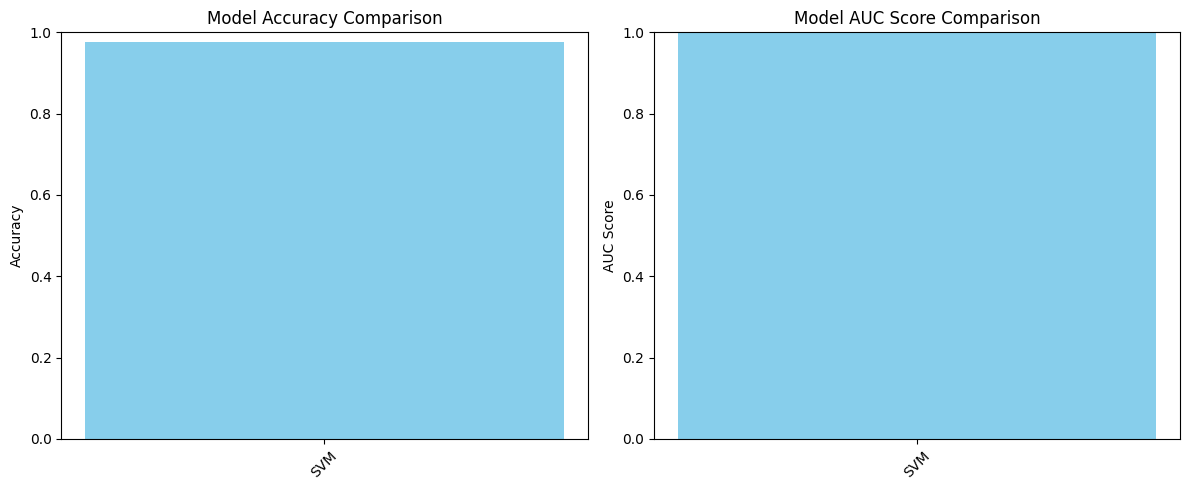

In [31]:
# Visualize model comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(comparison_df['Model'], comparison_df['Accuracy'], color=['skyblue', 'lightgreen', 'lightcoral'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.subplot(1, 2, 2)
plt.bar(comparison_df['Model'], comparison_df['AUC Score'], color=['skyblue', 'lightgreen', 'lightcoral'])
plt.title('Model AUC Score Comparison')
plt.ylabel('AUC Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


In [32]:
# ## Detailed Analysis of Best Model

# %%
# Get the best model based on accuracy
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
print(f"Best Model: {best_model_name}")


Best Model: SVM


In [33]:
# Detailed evaluation of best model
if best_model_name == 'SVM':
    y_pred_best = best_model.predict(X_test_scaled)
    y_pred_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_pred_best = best_model.predict(X_test)
    y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]


In [34]:
# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_best))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.97      0.97      0.97        31

    accuracy                           0.98        84
   macro avg       0.97      0.97      0.97        84
weighted avg       0.98      0.98      0.98        84



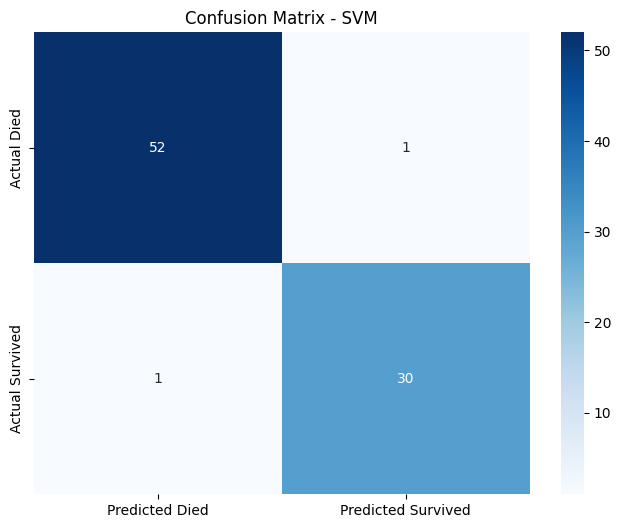

In [35]:
# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=['Predicted Died', 'Predicted Survived'],
           yticklabels=['Actual Died', 'Actual Survived'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()


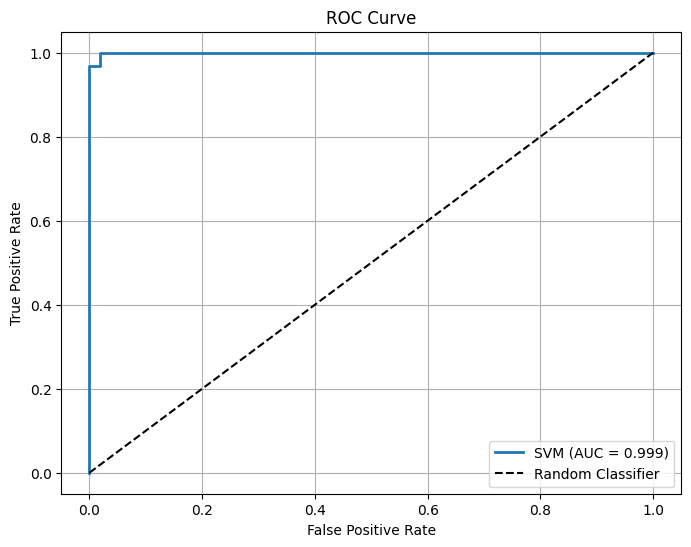

In [36]:
# ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
plt.plot(fpr, tpr, linewidth=2, label=f'{best_model_name} (AUC = {results[best_model_name]["auc_score"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()


In [37]:
# ## Feature Importance (for tree-based models)

# %%
if hasattr(best_model, 'feature_importances_'):
    # Get feature importance
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
    print("Feature Importance:")
    print(feature_importance)


In [38]:
 # Hyperparameter tuning for Random Forest (if it's the best model)
if best_model_name == 'Random Forest':
    print("Performing hyperparameter tuning for Random Forest...")
    
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    rf_tuned = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(rf_tuned, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    print("Best parameters:", grid_search.best_params_)
    print("Best cross-validation score:", grid_search.best_score_)



In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris  # or use your own dataset

# Example dataset
data = load_iris()
X = data.data
y = data.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Base model
rf = RandomForestClassifier(random_state=42)

# Parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

# Grid search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Evaluate tuned model
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned model accuracy on test set: {accuracy_tuned:.4f}")




Tuned model accuracy on test set: 1.0000


In [40]:
from sklearn.preprocessing import StandardScaler

# Split your data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit scaler only on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # scale test data using same scaler



In [41]:
# Assuming best_model is SVM and expects scaled data
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='accuracy')


In [42]:
# Perform cross-validation on the best model
print(f"Cross-validation for {best_model_name}:")
if best_model_name == 'SVM':
    cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
else:
    cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Cross-validation for SVM:
Cross-validation scores: [0.95833333 1.         0.83333333 1.         0.95833333]
Mean CV accuracy: 0.9500 (+/- 0.1225)


In [43]:
print("=" * 50)
print("FINAL MODEL SUMMARY")
print("=" * 50)
print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"AUC Score: {results[best_model_name]['auc_score']:.4f}")

try:
    print(f"Features used: {list(X.columns)}")
except AttributeError:
    print(f"Features used: Feature names not available (X is a NumPy array)")

print("=" * 50)





FINAL MODEL SUMMARY
Best Model: SVM
Test Accuracy: 0.9762
AUC Score: 0.9994
Features used: Feature names not available (X is a NumPy array)


In [44]:
# Save the best model and preprocessing objects
import joblib

model_artifacts = {
    'model': best_model,
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_columns': [f'feature_{i}' for i in range(X.shape[1])]
}

joblib.dump(model_artifacts, 'titanic_model.pkl')
print("Model and preprocessing artifacts saved as 'titanic_model.pkl'")



Model and preprocessing artifacts saved as 'titanic_model.pkl'


In [45]:
# ## Prediction on New Data Example

# %%
# Example of how to make predictions on new data
def predict_survival(model_artifacts, new_passenger_data):
    """
    Predict survival for new passenger data
    """
    model = model_artifacts['model']
    scaler = model_artifacts['scaler']
    label_encoders = model_artifacts['label_encoders']
    feature_columns = model_artifacts['feature_columns']
    



In [46]:
# Create a dataframe with the new data
# Example assuming order: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
new_passenger_data = [3, 'male', 25, 0, 0, 7.25, 'S']
feature_names = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

# Create DataFrame with column names
new_df = pd.DataFrame([new_passenger_data], columns=feature_names)



In [47]:
 # Preprocess the new data (same steps as training)
    # Feature engineering
new_df['FamilySize'] = new_df['SibSp'] + new_df['Parch'] + 1
new_df['IsAlone'] = (new_df['FamilySize'] == 1).astype(int)


In [48]:
# Age groups
new_df['AgeGroup'] = pd.cut(new_df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                        labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])


In [49]:
# Fare groups
if new_df['Fare'].nunique() > 1:
    new_df['FareGroup'] = pd.qcut(new_df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'], duplicates='drop')
else:
    new_df['FareGroup'] = 'Low'  # or assign a default group



In [50]:
 # Encode categorical variables
for col in ['Sex', 'Embarked', 'AgeGroup', 'FareGroup']:
    if col in label_encoders:
        # Handle unseen labels
        le = label_encoders[col]
        unique_labels = set(le.classes_)
        current_value = str(new_df[col].iloc[0])
            
        if current_value not in unique_labels:
            # Use the most common label as default
            new_df[col] = le.transform([le.classes_[0]])[0]
        else:
            new_df[col] = le.transform([current_value])[0]
    


In [51]:
feature_columns = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']  # example





In [52]:
model_artifacts = {
    'model': best_model,
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_columns': feature_columns  # This should be defined during training
}


In [53]:
import joblib

# Load the model and artifacts
artifacts = joblib.load('titanic_model.pkl')
model = artifacts['model']
scaler = artifacts['scaler']
label_encoders = artifacts['label_encoders']
feature_columns = artifacts['feature_columns']


In [54]:
feature_columns = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
new_df = new_df[feature_columns]




In [55]:
feature_columns = model_artifacts['feature_columns']  # loaded from model



In [56]:
# Example: Create AgeGroup and FareGroup like during training
# Make sure 'Age' and 'Fare' exist
if 'Age' in new_df.columns:
    new_df['AgeGroup'] = pd.cut(
        new_df['Age'],
        bins=[0, 12, 18, 50, 100],
        labels=['Child', 'Teen', 'Adult', 'Senior']
    )

if 'Fare' in new_df.columns:
    try:
        new_df['FareGroup'] = pd.qcut(
            new_df['Fare'],
            q=4,
            labels=['Low', 'Medium', 'High', 'Very High'],
            duplicates='drop'  # avoid bin edge errors
        )
    except ValueError as e:
        print("FareGroup creation failed:", e)

# Now apply label encoders — only for columns that exist
for col, le in label_encoders.items():
    if col in new_df.columns:
        if new_df[col].dtype == object or isinstance(new_df[col].iloc[0], str):
            try:
                new_df[col] = le.transform(new_df[col])
            except ValueError as e:
                print(f"Encoding error in '{col}': {e}")
                new_df[col] = -1  # fallback for unknown label



FareGroup creation failed: Bin labels must be one fewer than the number of bin edges


In [57]:
import joblib
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']  # adjust based on your training pipeline




In [58]:
artifacts = joblib.load('titanic_model.pkl')
model = artifacts['model']
scaler = artifacts['scaler']
label_encoders = artifacts['label_encoders']
feature_columns = artifacts['feature_columns']
artifacts['numerical_features'] = numerical_features
joblib.dump(artifacts, 'titanic_model.pkl')


['titanic_model.pkl']

In [59]:
# Example prediction
example_passenger = {
    'Pclass': 1,
    'Sex': 'female',
    'Age': 25,
    'SibSp': 0,
    'Parch': 0,
    'Fare': 50,
    'Embarked': 'S'
}


In [60]:
def predict_survival(artifacts, passenger_dict):
    import pandas as pd
    from sklearn.svm import SVC

    model = artifacts['model']
    scaler = artifacts['scaler']
    label_encoders = artifacts['label_encoders']
    feature_columns = artifacts['feature_columns']
    numerical_features = artifacts.get('numerical_features', ['Age', 'Fare', 'SibSp', 'Parch'])  # fallback

    # Step 1: Create DataFrame
    new_df = pd.DataFrame([passenger_dict])

    # Step 2: Handle missing engineered columns if needed
    if 'AgeGroup' not in new_df.columns and 'Age' in new_df.columns:
        new_df['AgeGroup'] = pd.cut(new_df['Age'], bins=[0, 12, 18, 50, 100], labels=['Child', 'Teen', 'Adult', 'Senior'])

    if 'FareGroup' not in new_df.columns and 'Fare' in new_df.columns:
        try:
            new_df['FareGroup'] = pd.qcut(new_df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'], duplicates='drop')
        except ValueError:
            new_df['FareGroup'] = 'Low'  # fallback for identical fares

    # Step 3: Apply label encoders
    for col, le in label_encoders.items():
        if col in new_df.columns:
            try:
                new_df[col] = le.transform(new_df[col])
            except ValueError:
                # Handle unseen label
                new_df[col] = le.transform([le.classes_[0]])[0]

    # Step 4: Select only relevant features
    try:
        new_df = new_df[feature_columns]
    except KeyError as e:
        missing = list(set(feature_columns) - set(new_df.columns))
        raise ValueError(f"Missing features for prediction: {missing}")

    # Step 5: Scale numerical features
    new_df_scaled = new_df.copy()
    new_df_scaled[numerical_features] = scaler.transform(new_df[numerical_features])

    # Step 6: Predict
    if isinstance(model, SVC):
        prediction = model.predict(new_df_scaled)
        probability = model.predict_proba(new_df_scaled)
    else:
        prediction = model.predict(new_df_scaled)
        probability = model.predict_proba(new_df_scaled)

    return prediction[0], probability[0]


In [61]:
def predict_survival(artifacts, passenger_data):
    import pandas as pd

    model = artifacts['model']
    scaler = artifacts['scaler']
    label_encoders = artifacts['label_encoders']
    feature_columns = artifacts['feature_columns']

    # Convert dict to DataFrame
    new_df = pd.DataFrame([passenger_data])

    # Apply label encoding
    for col, le in label_encoders.items():
        if col in new_df.columns:
            new_df[col] = le.transform(new_df[col])

    # Select correct features
    new_df = new_df[feature_columns]

    # Scale if needed
    if hasattr(model, 'predict_proba'):
        new_df_scaled = scaler.transform(new_df)
        prediction = model.predict(new_df_scaled)
        probability = model.predict_proba(new_df_scaled)
    else:
        prediction = model.predict(new_df)
        probability = model.predict_proba(new_df)

    return prediction[0], probability[0]


In [62]:
import joblib

# Bundle everything into one dictionary
model_artifacts = {
    'model': best_model,
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_columns': feature_columns
}

# Save to disk
joblib.dump(model_artifacts, 'titanic_model_artifacts.pkl')


['titanic_model_artifacts.pkl']

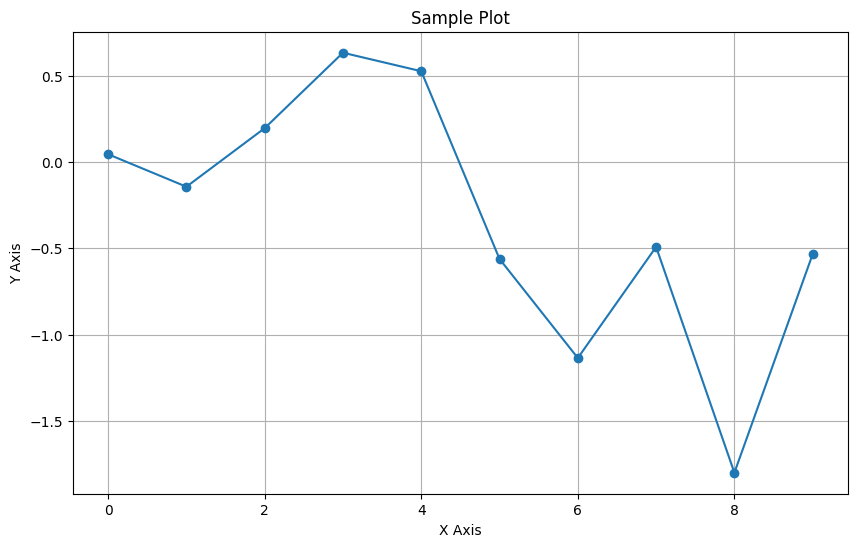

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Sample data
df = pd.DataFrame({
    'x': range(10),
    'y': np.random.randn(10)
})

# Create a plot
plt.figure(figsize=(10, 6))
plt.plot(df['x'], df['y'], marker='o')
plt.title('Sample Plot')
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.grid(True)

# Save in different formats
plt.savefig('plot.png', dpi=300, bbox_inches='tight')           # PNG (high quality)
plt.savefig('plot.jpg', dpi=300, bbox_inches='tight')           # JPEG
plt.savefig('plot.pdf', bbox_inches='tight')                    # PDF (vector)
plt.savefig('plot.svg', bbox_inches='tight')                    # SVG (vector)
plt.savefig('plot.tiff', dpi=300, bbox_inches='tight')         # TIFF

plt.show()


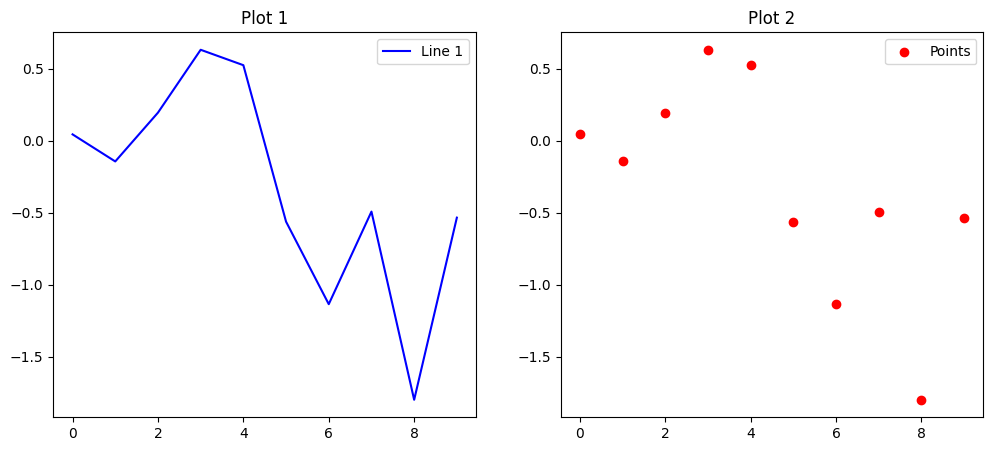

In [64]:
# Multiple plots in one figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(df['x'], df['y'], 'b-', label='Line 1')
ax1.set_title('Plot 1')
ax1.legend()

ax2.scatter(df['x'], df['y'], color='red', label='Points')
ax2.set_title('Plot 2')
ax2.legend()

# Save with custom settings
plt.savefig('multi_plot.png', 
           dpi=300, 
           bbox_inches='tight',
           facecolor='white',    # Background color
           edgecolor='black',    # Border color
           transparent=False)    # Transparent background

plt.show()

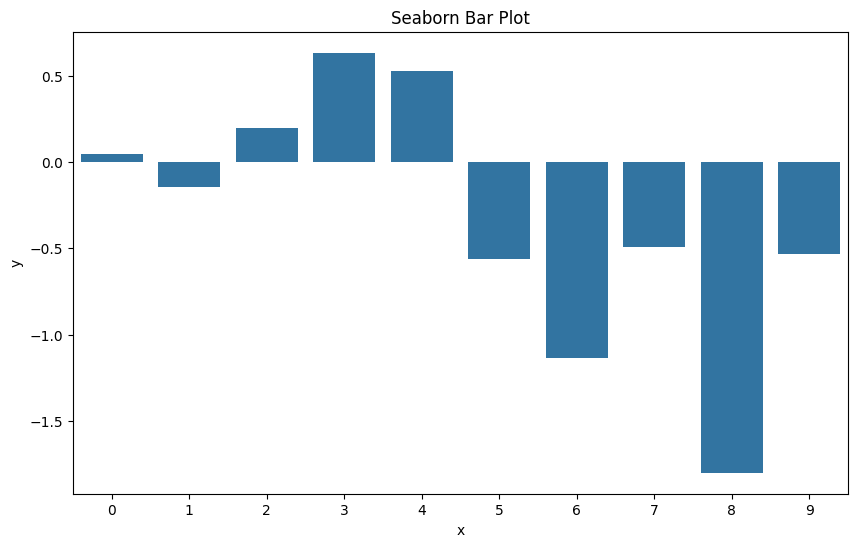

In [65]:
# Seaborn plot
plt.figure(figsize=(10, 6))
sns.barplot(x='x', y='y', data=df)
plt.title('Seaborn Bar Plot')

# Save with high resolution
plt.savefig('seaborn_plot.png', 
           dpi=300, 
           bbox_inches='tight',
           pad_inches=0.1)      # Padding around the plot

plt.show()

In [66]:
import pandas as pd

# Sample DataFrame
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Diana'],
    'Age': [25, 30, 35, 28],
    'City': ['New York', 'London', 'Tokyo', 'Paris'],
    'Salary': [50000, 60000, 70000, 55000]
}
df = pd.DataFrame(data)

# Basic CSV save
df.to_csv('data.csv', index=False)

# Advanced CSV options
df.to_csv('data_advanced.csv', 
         index=False,           # Don't save row indices
         sep=',',              # Separator
         encoding='utf-8',     # Encoding
         header=True,          # Include column names
         na_rep='NULL')        # How to represent NaN values

# Save with specific columns
df[['Name', 'Salary']].to_csv('name_salary.csv', index=False)

# Save with custom formatting
df.to_csv('formatted_data.csv', 
         index=False,
         float_format='%.2f')  # Format floating numbers


In [67]:
# Read CSV
df_read = pd.read_csv('data.csv')
print("Original data:")
print(df_read)



Original data:
      Name  Age      City  Salary
0    Alice   25  New York   50000
1      Bob   30    London   60000
2  Charlie   35     Tokyo   70000
3    Diana   28     Paris   55000


In [68]:
# Modify and save again
df_read['Bonus'] = df_read['Salary'] * 0.1
df_read.to_csv('data_with_bonus.csv', index=False)


In [69]:
# Append to existing CSV (careful - this can create headers multiple times)
# Better approach: read, modify, then save
existing_df = pd.read_csv('titanic.csv')
new_data = pd.DataFrame({
    'Name': ['Eve'],
    'Age': [32],
    'City': ['Berlin'],
    'Salary': [65000]
})
import pandas as pd

# Read existing data
existing_df = pd.read_csv('data.csv')

# Create new data to append
new_data = pd.DataFrame({
    'Name': ['Eve'],
    'Age': [32],
    'City': ['Berlin'],
    'Salary': [65000]
})

# Combine and save to a new CSV
combined_df = pd.concat([existing_df, new_data], ignore_index=True)
combined_df.to_csv('updated_data.csv', index=False)


In [70]:
import zipfile
import os
from io import BytesIO

# Method 1: Create ZIP from existing files
def create_zip_from_files(files_list, zip_filename):
    with zipfile.ZipFile(zip_filename, 'w') as zipf:
        for file in files_list:
            if os.path.exists(file):
                zipf.write(file, os.path.basename(file))
                print(f"Added {file} to {zip_filename}")

# Method 2: Create ZIP from DataFrames (without saving intermediate files)
def create_zip_from_dataframes(dataframes_dict, zip_filename):
    with zipfile.ZipFile(zip_filename, 'w') as zipf:
        for filename, df in dataframes_dict.items():
            # Create CSV in memory
            csv_buffer = BytesIO()
            df.to_csv(csv_buffer, index=False)
            
            # Add to ZIP
            zipf.writestr(f"{filename}.csv", csv_buffer.getvalue())
            print(f"Added {filename}.csv to {zip_filename}")

# Method 3: Add plots to ZIP
def add_plots_to_zip(plot_functions, zip_filename):
    with zipfile.ZipFile(zip_filename, 'a') as zipf:  # 'a' for append
        for i, plot_func in enumerate(plot_functions):
            # Create and save plot to buffer
            plt.figure(figsize=(10, 6))
            plot_func()
            
            # Save plot to buffer
            plot_buffer = BytesIO()
            plt.savefig(plot_buffer, format='png', dpi=300, bbox_inches='tight')
            plt.close()
            
            # Add to ZIP
            zipf.writestr(f'plot_{i+1}.png', plot_buffer.getvalue())
            print(f"Added plot_{i+1}.png to {zip_filename}")


In [71]:
# Example 1: Create sample data and save multiple files
# Create some sample DataFrames
df1 = pd.DataFrame({'A': range(5), 'B': range(5, 10)})
df2 = pd.DataFrame({'X': ['a', 'b', 'c'], 'Y': [1, 2, 3]})

# Save individual files first
df1.to_csv('dataframe1.csv', index=False)
df2.to_csv('dataframe2.csv', index=False)

# Create a plot and save it
plt.figure(figsize=(8, 6))
plt.plot(df1['A'], df1['B'], 'ro-')
plt.title('Sample Plot')
plt.savefig('sample_plot.png', dpi=300, bbox_inches='tight')
plt.close()

# Create ZIP from existing files
files_to_zip = ['dataframe1.csv', 'dataframe2.csv', 'sample_plot.png']
create_zip_from_files(files_to_zip, 'my_files.zip')

# Example 2: Create ZIP directly from DataFrames (no intermediate files)
dataframes = {
    'employees': pd.DataFrame({
        'Name': ['Alice', 'Bob', 'Charlie'],
        'Department': ['IT', 'HR', 'Finance'],
        'Salary': [70000, 65000, 80000]
    }),
    'departments': pd.DataFrame({
        'DeptID': [1, 2, 3],
        'DeptName': ['IT', 'HR', 'Finance'],
        'Budget': [1000000, 500000, 1200000]
    })
}

create_zip_from_dataframes(dataframes, 'company_data.zip')

# Example 3: Add plots to existing ZIP
def create_plot1():
    x = np.linspace(0, 10, 100)
    y = np.sin(x)
    plt.plot(x, y)
    plt.title('Sine Wave')
    plt.grid(True)

def create_plot2():
    categories = ['A', 'B', 'C', 'D']
    values = [23, 45, 56, 78]
    plt.bar(categories, values, color=['red', 'blue', 'green', 'orange'])
    plt.title('Bar Chart')

plot_functions = [create_plot1, create_plot2]
add_plots_to_zip(plot_functions, 'plots_only.zip')


Added dataframe1.csv to my_files.zip
Added dataframe2.csv to my_files.zip
Added sample_plot.png to my_files.zip
Added employees.csv to company_data.zip
Added departments.csv to company_data.zip
Added plot_1.png to plots_only.zip
Added plot_2.png to plots_only.zip


In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
from io import BytesIO
import os

def complete_analysis_pipeline():
    """Complete example: create data, plots, and package everything"""
    
    # Create sample data
    np.random.seed(42)
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
    sales_data = pd.DataFrame({
        'Month': months,
        'Product_A': np.random.randint(100, 500, 6),
        'Product_B': np.random.randint(80, 400, 6),
        'Product_C': np.random.randint(120, 600, 6)
    })
    
    # Create multiple plots
    def create_sales_plot():
        plt.figure(figsize=(12, 6))
        plt.plot(sales_data['Month'], sales_data['Product_A'], 'o-', label='Product A')
        plt.plot(sales_data['Month'], sales_data['Product_B'], 's-', label='Product B')
        plt.plot(sales_data['Month'], sales_data['Product_C'], '^-', label='Product C')
        plt.title('Monthly Sales')
        plt.xlabel('Month')
        plt.ylabel('Sales')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    def create_bar_plot():
        plt.figure(figsize=(10, 6))
        sales_data.set_index('Month')[['Product_A', 'Product_B', 'Product_C']].plot(kind='bar')
        plt.title('Sales by Product and Month')
        plt.ylabel('Sales')
        plt.xticks(rotation=45)
    
    # Create ZIP with everything
    with zipfile.ZipFile('complete_analysis.zip', 'w') as zipf:
        
        # 1. Add CSV data
        csv_buffer = BytesIO()
        sales_data.to_csv(csv_buffer, index=False)
        zipf.writestr('sales_data.csv', csv_buffer.getvalue())
        
        # 2. Add plots
        plot_functions = [create_sales_plot, create_bar_plot]
        for i, plot_func in enumerate(plot_functions):
            plt.figure(figsize=(10, 6))
            plot_func()
            
            plot_buffer = BytesIO()
            plt.savefig(plot_buffer, format='png', dpi=300, bbox_inches='tight')
            plt.close()
            
            zipf.writestr(f'plot_{i+1}.png', plot_buffer.getvalue())
        
        # 3. Add summary statistics
        summary = sales_data.describe().to_string()
        zipf.writestr('summary_statistics.txt', summary)
    
    print("Complete analysis package saved as 'complete_analysis.zip'")
    
    # List contents of ZIP file
    with zipfile.ZipFile('complete_analysis.zip', 'r') as zipf:
        print("\nContents of ZIP file:")
        for file_info in zipf.infolist():
            print(f"  - {file_info.filename}")

# Run the complete pipeline
complete_analysis_pipeline()


Complete analysis package saved as 'complete_analysis.zip'

Contents of ZIP file:
  - sales_data.csv
  - plot_1.png
  - plot_2.png
  - summary_statistics.txt


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [73]:
!pip install openpyxl



Defaulting to user installation because normal site-packages is not writeable


In [74]:
# Save as Excel
df.to_excel('data.xlsx', index=False, sheet_name='Sheet1')

# Save as JSON
df.to_json('data.json', orient='records', indent=2)

# Save as HTML table
df.to_html('data.html', index=False)

# Save as Pickle (Python object)
df.to_pickle('data.pkl')

# Save multiple sheets to Excel
with pd.ExcelWriter('multiple_sheets.xlsx') as writer:
    df.to_excel(writer, sheet_name='Data', index=False)
    df.describe().to_excel(writer, sheet_name='Summary')

In [75]:
def cleanup_files(file_list):
    """Clean up temporary files"""
    for file in file_list:
        if os.path.exists(file):
            os.remove(file)
            print(f"Removed {file}")

# Usage
temp_files = ['dataframe1.csv', 'dataframe2.csv', 'sample_plot.png']
cleanup_files(temp_files)

Removed dataframe1.csv
Removed dataframe2.csv
Removed sample_plot.png
